In [2]:
import fitz
import os, hashlib

pdf_path = "./Meg_proj.pdf"
out_dir = "images"
os.makedirs(out_dir, exist_ok=True)

doc = fitz.open(pdf_path)

def sha256_bytes(b: bytes) -> str:
    return hashlib.sha256(b).hexdigest()

# 读取已有图片的哈希（让脚本对历史有记忆）
existing_hashes = set()
for fn in os.listdir(out_dir):
    path = os.path.join(out_dir, fn)
    if os.path.isfile(path):
        with open(path, "rb") as f:
            existing_hashes.add(sha256_bytes(f.read()))

print("Number of pages in PDF:", len(doc))
saved = 0
skipped = 0

for page_index in range(len(doc)):
    page = doc[page_index]
    for img in page.get_images(full=True):
        xref = img[0]
        base = doc.extract_image(xref)
        image_bytes = base["image"]
        ext = base["ext"]

        h = sha256_bytes(image_bytes)
        if h in existing_hashes:
            skipped += 1
            continue

        # 用哈希命名：永远稳定、不会冲突
        fname = os.path.join(out_dir, f"img_{h[:16]}.{ext}")
        with open(fname, "wb") as f:
            f.write(image_bytes)

        existing_hashes.add(h)
        saved += 1

print(f"Saved {saved} new images; skipped {skipped} duplicates.")

Number of pages in PDF: 208
Saved 0 new images; skipped 208 duplicates.


In [33]:
import os, shutil, glob
import numpy as np
from PIL import Image

src = "../png"
out = "../png_sub"
os.makedirs(out, exist_ok=True)

paths = sorted(glob.glob(os.path.join(src, "*.png")))
print("Images:", len(paths))

def load_gray_small(p, scale=0.25):
    im = Image.open(p).convert("L")
    w, h = im.size
    im = im.resize((max(32, int(w*scale)), max(32, int(h*scale))), Image.Resampling.BILINEAR)
    return np.asarray(im, dtype=np.float32)

def blur_score(p):
    # Laplacian variance without cv2
    x = load_gray_small(p, 0.25)
    # 2D Laplacian kernel
    k = np.array([[0, 1, 0],
                  [1,-4, 1],
                  [0, 1, 0]], dtype=np.float32)
    # convolution (valid)
    y = (
        k[0,0]*x[:-2,:-2] + k[0,1]*x[:-2,1:-1] + k[0,2]*x[:-2,2:] +
        k[1,0]*x[1:-1,:-2] + k[1,1]*x[1:-1,1:-1] + k[1,2]*x[1:-1,2:] +
        k[2,0]*x[2:,:-2] + k[2,1]*x[2:,1:-1] + k[2,2]*x[2:,2:]
    )
    return float(np.var(y))

def dhash(p, hash_size=16):
    # difference hash (very fast, robust enough for grouping)
    im = Image.open(p).convert("L").resize((hash_size+1, hash_size), Image.Resampling.BILINEAR)
    arr = np.asarray(im, dtype=np.float32)
    diff = arr[:,1:] > arr[:,:-1]
    # pack to bytes
    return diff.flatten()

def hamming(a, b):
    return int(np.count_nonzero(a != b))

# 1) keep sharpest 70%
scores = [(p, blur_score(p)) for p in paths]
scores.sort(key=lambda x: x[1], reverse=True)
keep = scores[: max(20, int(0.7*len(scores)))]
keep_paths = [p for p,_ in keep]
print("Kept (sharp):", len(keep_paths))

# 2) build similarity graph via dhash
hashes = {p: dhash(p) for p in keep_paths}

# Compare only within sliding window to keep it fast.
# If your filenames are mixed, this window may miss links;
# set window=None to compare all pairs (slower but safer for 200 imgs).
window = None  # set to e.g. 40 if your list is roughly grouped

edges = {p: [] for p in keep_paths}
thr = 55  # smaller = stricter (more similar). 55/256 is moderate.

if window is None:
    for i,p in enumerate(keep_paths):
        for j in range(i+1, len(keep_paths)):
            q = keep_paths[j]
            if hamming(hashes[p], hashes[q]) <= thr:
                edges[p].append(q); edges[q].append(p)
else:
    for i,p in enumerate(keep_paths):
        for j in range(max(0, i-window), min(len(keep_paths), i+window+1)):
            if i == j: continue
            q = keep_paths[j]
            if hamming(hashes[p], hashes[q]) <= thr:
                edges[p].append(q); edges[q].append(p)

# 3) largest connected component (BFS)
seen = set()
best = []
for p in keep_paths:
    if p in seen: continue
    comp = []
    stack = [p]
    seen.add(p)
    while stack:
        u = stack.pop()
        comp.append(u)
        for v in edges[u]:
            if v not in seen:
                seen.add(v); stack.append(v)
    if len(comp) > len(best):
        best = comp

print("Largest component:", len(best))
for p in best:
    shutil.copy2(p, os.path.join(out, os.path.basename(p)))
print("Wrote subset to:", out)

Images: 0
Kept (sharp): 0
Largest component: 0
Wrote subset to: ../png_sub


#### COLMAP SQLite Command Lines for Non-sequential Image Scans
##### DB Sanity Check
```python
# ============================================================
# DB sanity checks (FULL) — ws_208_spatial_v1
# ============================================================
ROOT="/Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning"
DB="$ROOT/colmap_ws/ws_208_spatial_v1/db.db"

sqlite3 "$DB" "SELECT COUNT(*) FROM matches;"
sqlite3 "$DB" "SELECT COUNT(*) FROM two_view_geometries;"
sqlite3 "$DB" "SELECT COUNT(*) FROM two_view_geometries WHERE rows > 0;"


# ============================================================
# DB sanity checks (FULL) — ws_208_exhaustive_v1
# ============================================================
ROOT="/Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning"
DB="$ROOT/colmap_clean.db"

sqlite3 "$DB" "SELECT COUNT(*) FROM matches;"
sqlite3 "$DB" "SELECT COUNT(*) FROM two_view_geometries;"
sqlite3 "$DB" "SELECT COUNT(*) FROM two_view_geometries WHERE rows > 0;"
```

##### VTK Parameters Check
```python
colmap model_analyzer --path "$ROOT/colmap_ws/ws_208_exhaustive_v1/sparse/0"
# ============================================================
# FULL model-parameter checks — ws_208_spatial_v1 + ws_208_exhaustive_v1
# (Lists models, runs model_analyzer, and optionally exports TXT for inspection)
# ============================================================

check_models () {
  local WS="$1"
  local SPARSE="$WS/sparse"
  local TXTROOT="$WS/txt_models"

  echo
  echo "============================================================"
  echo "MODEL CHECK: $WS"
  echo "============================================================"

  if [ ! -d "$SPARSE" ]; then
    echo "[ERROR] Missing sparse folder: $SPARSE"
    return 1
  fi

  echo "[list] models under: $SPARSE"
  ls -lah "$SPARSE"

  echo
  echo "[analyze] colmap model_analyzer for each model:"
  for m in "$SPARSE"/*; do
    [ -d "$m" ] || continue
    echo "----- MODEL $(basename "$m") -----"
    colmap model_analyzer --path "$m"
  done

  # Optional: export TXT for each model (cameras.txt/images.txt/points3D.txt)
  # Useful when you want to inspect exact parameters and file contents.
  echo
  echo "[export] TXT models to: $TXTROOT"
  mkdir -p "$TXTROOT"
  for m in "$SPARSE"/*; do
    [ -d "$m" ] || continue
    local name
    name="$(basename "$m")"
    mkdir -p "$TXTROOT/$name"
    colmap model_converter --input_path "$m" --output_path "$TXTROOT/$name" --output_type TXT >/dev/null 2>&1 || true
  done

  echo "[done] TXT exported (if models existed). Example:"
  echo "  ls -lah \"$TXTROOT/0\""
}

# ---- Run for both workspaces ----
check_models "/Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning/colmap_ws/ws_208_spatial_v1"
check_models "/Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning/colmap_ws/ws_208_exhaustive_v1"
```

##### Factory A — ws_208_spatial_v1 (Non-sequential, spatial matching)
```python
ROOT="/Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning"
IMG="$ROOT/images_clean"
WS="$ROOT/colmap_ws/ws_208_spatial_v1"

DB="$WS/db.db"
SPARSE="$WS/sparse"
TXT="$WS/txt"
LOG="$WS/logs"

mkdir -p "$SPARSE" "$TXT" "$LOG"

# 0) sanity: confirm exactly 208 png/jpg/jpeg
echo "[check] image count:"
find "$IMG" -maxdepth 1 -type f \( -iname "*.png" -o -iname "*.jpg" -o -iname "*.jpeg" \) | wc -l

# 1) fresh DB
rm -f "$DB" "$DB-wal" "$DB-shm"
colmap database_creator --database_path "$DB" 2>&1 | tee "$LOG/01_db.txt"

# 2) feature extraction (CPU; no OpenGL)
colmap feature_extractor \
  --database_path "$DB" \
  --image_path "$IMG" \
  --FeatureExtraction.use_gpu 0 \
  --ImageReader.single_camera 1 \
  2>&1 | tee "$LOG/02_feat.txt"

# quick DB check
echo "[check] DB images/keypoints:"
sqlite3 "$DB" "SELECT COUNT(*) FROM images;"
sqlite3 "$DB" "SELECT COUNT(*) FROM keypoints;"

# 3) spatial matching (for non-sequential capture)
colmap spatial_matcher \
  --database_path "$DB" \
  --FeatureMatching.use_gpu 0 \
  2>&1 | tee "$LOG/03_match_spatial.txt"

# verify matches exist
echo "[check] matches/two_view_geometries:"
sqlite3 "$DB" "SELECT COUNT(*) FROM matches;"
sqlite3 "$DB" "SELECT COUNT(*) FROM two_view_geometries;"
sqlite3 "$DB" "SELECT COUNT(*) FROM two_view_geometries WHERE rows > 0;"

# 4) mapper
rm -rf "$SPARSE"
mkdir -p "$SPARSE"
colmap mapper \
  --database_path "$DB" \
  --image_path "$IMG" \
  --output_path "$SPARSE" \
  2>&1 | tee "$LOG/04_mapper.txt"

# 5) model stats (the output like your screenshot)
echo "[model_analyzer]"
colmap model_analyzer --path "$SPARSE/0" 2>&1 | tee "$LOG/05_analyzer.txt"

# 6) export TXT (cameras.txt / images.txt / points3D.txt)
rm -rf "$TXT"
mkdir -p "$TXT"
colmap model_converter \
  --input_path "$SPARSE/0" \
  --output_path "$TXT" \
  --output_type TXT \
  2>&1 | tee "$LOG/06_txt.txt"

echo "DONE. TXT model here: $TXT"
ls -lah "$TXT"
```

##### Factory B — ws_208_exhaustive_v1 (Most stable, exhaustive matching)
```python
ROOT="/Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning"
IMG="$ROOT/images_clean"
WS="$ROOT/colmap_ws/ws_208_exhaustive_v1"

DB="$WS/db.db"
SPARSE="$WS/sparse"
TXT="$WS/txt"
LOG="$WS/logs"

mkdir -p "$SPARSE" "$TXT" "$LOG"

echo "[check] image count:"
find "$IMG" -maxdepth 1 -type f \( -iname "*.png" -o -iname "*.jpg" -o -iname "*.jpeg" \) | wc -l

rm -f "$DB" "$DB-wal" "$DB-shm"
colmap database_creator --database_path "$DB" 2>&1 | tee "$LOG/01_db.txt"

colmap feature_extractor \
  --database_path "$DB" \
  --image_path "$IMG" \
  --FeatureExtraction.use_gpu 0 \
  --ImageReader.single_camera 1 \
  2>&1 | tee "$LOG/02_feat.txt"

echo "[check] DB images/keypoints:"
sqlite3 "$DB" "SELECT COUNT(*) FROM images;"
sqlite3 "$DB" "SELECT COUNT(*) FROM keypoints;"

# exhaustive matching (you'll see Processing block [i/?, j/?] logs)
colmap exhaustive_matcher \
  --database_path "$DB" \
  --FeatureMatching.use_gpu 0 \
  2>&1 | tee "$LOG/03_match_exhaustive.txt"

echo "[check] matches/two_view_geometries:"
sqlite3 "$DB" "SELECT COUNT(*) FROM matches;"
sqlite3 "$DB" "SELECT COUNT(*) FROM two_view_geometries;"
sqlite3 "$DB" "SELECT COUNT(*) FROM two_view_geometries WHERE rows > 0;"

rm -rf "$SPARSE"
mkdir -p "$SPARSE"
colmap mapper \
  --database_path "$DB" \
  --image_path "$IMG" \
  --output_path "$SPARSE" \
  2>&1 | tee "$LOG/04_mapper.txt"

echo "[model_analyzer]"
colmap model_analyzer --path "$SPARSE/0" 2>&1 | tee "$LOG/05_analyzer.txt"

rm -rf "$TXT"
mkdir -p "$TXT"
colmap model_converter \
  --input_path "$SPARSE/0" \
  --output_path "$TXT" \
  --output_type TXT \
  2>&1 | tee "$LOG/06_txt.txt"

echo "DONE (exhaustive). TXT model at: $TXT"
ls -lah "$TXT"
```

colmap feature_extractor --database_path db.db --image_path . --FeatureExtraction.use_gpu 0 --ImageReader.single_camera 1

colmap exhaustive_matcher --database_path db.db --FeatureMatching.use_gpu 0

mkdir -p sparse_out

colmap mapper --database_path db.db --image_path . --output_path sparse_out

#### COLMAP SQLite Diagnostic — KaTeX Parse
```python
(base)(.venv313) eliguli712@Eligulis-MBP ~/DataStructure/numerical_analysis/FEA_meg/scanning/images/png % sqlite3 db.db "PRAGMA wal_checkpoint(FULL);"
0|0|0
(base)(.venv313) eliguli712@Eligulis-MBP ~/DataStructure/numerical_analysis/FEA_meg/scanning/images/png % sqlite3 db.db ".tables"
sqlite3 db.db "SELECT COUNT(*) AS images FROM images;"
sqlite3 db.db "SELECT COUNT(*) AS keypoints_rows FROM keypoints;"
sqlite3 db.db "SELECT COUNT(*) AS matches_rows FROM matches;"
sqlite3 db.db "SELECT COUNT(*) AS two_view_geoms FROM two_view_geometries;"
sqlite3 db.db "SELECT COUNT(*) AS verified_geoms FROM two_view_geometries WHERE rows > 0;"
cameras              images               rig_sensors        
descriptors          keypoints            rigs               
frame_data           matches              two_view_geometries
frames               pose_priors        
416
416
86320
86320
16690
```

#### File Descriptors
$$
\textbf{Database: }\mathtt{db.db}
$$

$$
\textbf{WAL Checkpoint}
$$

$$
\texttt{PRAGMA\ wal\_checkpoint(FULL)} \;\longrightarrow\; (0,\;0,\;0)
$$

$$
\begin{aligned}
0 &= \text{busy pages} \\
0 &= \text{log pages checkpointed} \\
0 &= \text{pages remaining}
\end{aligned}
$$

$$
\Rightarrow\; \text{The write-ahead log is empty and fully flushed.}
$$

---

$$
\textbf{Database Tables}
$$

$$
\{\;
\mathtt{cameras},\;
\mathtt{images},\;
\mathtt{descriptors},\;
\mathtt{keypoints},\;
\mathtt{matches},\;
\mathtt{two\_view\_geometries},\;
\mathtt{rigs},\;
\mathtt{rig\_sensors},\;
\mathtt{frames},\;
\mathtt{frame\_data},\;
\mathtt{pose\_priors}
\;\}
$$

---

$$
\textbf{Row Counts}
$$

$$
\begin{aligned}
|\texttt{images}| &= 416 \\
|\texttt{keypoints}| &= 416 \\
|\texttt{matches}| &= 86320 \\
|\texttt{two\_view\_geometries}| &= 86320 \\
|\texttt{two\_view\_geometries where rows > 0}| &= 16690
\end{aligned}
$$

---

$$
\textbf{Derived Structure}
$$

$$
\text{Image count} = 416
$$

$$
\text{Total image pairs} = 86320
$$

$$
\text{Geometrically verified pairs} = 16690
$$


$$\text{Verification ratio}
=
\frac{16690}{86320}
\approx 0.1934
\approx 19.3\%

$$
---


$$\boxed{
\text{COLMAP graph is populated, and two-view geometry exists for }\sim 19\% \text{ of all image pairs}
}
$$

#### Model Analyzer

colmap model_analyzer --path sparse_out/0

#### TXT Reconstruction
mkdir -p sparse_out/0_txt

colmap model_converter --input_path sparse_out/0 --output_path sparse_out/0_txt --output_type TXT

sqlite3 db.db "SELECT pair_id, rows FROM two_view_geometries WHERE rows > 0 ORDER BY rows DESC LIMIT 20;"

sqlite3 db.db "WITH pairs AS (SELECT pair_id, rows, CAST(pair_id/2147483647 AS INT) AS i1, (pair_id % 2147483647) AS i2 FROM two_view_geometries WHERE rows>0 ORDER BY rows DESC LIMIT 20) SELECT pairs.rows, pairs.i1, im1.name, pairs.i2, im2.name FROM pairs JOIN images im1 ON im1.image_id=pairs.i1 JOIN images im2 ON im2.image_id=pairs.i2;"

In [4]:
from __future__ import annotations
from pathlib import Path
import os
import numpy as np


def _resolve_points3d_path(p: str | Path) -> Path:
    """
    Resolve points3D.txt path robustly on macOS:
    - expands ~
    - if user passed /DataStructure/... (often wrong), try:
        ~/DataStructure/...
        /Users/<user>/DataStructure/...
    """
    p = Path(str(p)).expanduser()

    # If it already exists, great
    if p.exists():
        return p

    # Common mistake: leading "/DataStructure/..." instead of "~/DataStructure/..."
    s = str(p)
    if s.startswith("/DataStructure/"):
        tail = s[len("/DataStructure/"):]  # strip leading fake root
        candidates = [
            Path.home() / "DataStructure" / tail,
            Path(f"/Users/{os.getlogin()}/DataStructure") / tail,
        ]
        for c in candidates:
            c = c.expanduser()
            if c.exists():
                return c

    raise FileNotFoundError(f"points3D.txt not found. Tried: {p.resolve()}")


def convert_points3d_to_xyzrgb_txt_and_npy(
    points3d_path: str | Path,
    out_xyzrgb_txt: str | Path = "points_xyzrgb.txt",
    out_xyz_npy: str | Path = "points_xyz.npy",
    out_xyzrgb_npy: str | Path = "points_xyzrgb.npy",
) -> dict:
    """
    Convert COLMAP TXT-model points3D.txt into:
      - points_xyzrgb.txt : x y z r g b
      - points_xyz.npy    : Nx3 float64
      - points_xyzrgb.npy : Nx6 float64 (x,y,z,r,g,b) with rgb in [0,255]
    """
    points3d_path = _resolve_points3d_path(points3d_path)

    out_xyzrgb_txt = Path(out_xyzrgb_txt)
    out_xyz_npy = Path(out_xyz_npy)
    out_xyzrgb_npy = Path(out_xyzrgb_npy)

    xyz_list = []
    rgb_list = []
    err_list = []
    bad = 0

    with points3d_path.open("r", encoding="utf-8", errors="ignore") as fin:
        for line in fin:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            # id x y z r g b error ...
            if len(parts) < 8:
                bad += 1
                continue
            try:
                x = float(parts[1]); y = float(parts[2]); z = float(parts[3])
                r = int(parts[4]); g = int(parts[5]); b = int(parts[6])
                err = float(parts[7])
            except Exception:
                bad += 1
                continue

            r = max(0, min(255, r))
            g = max(0, min(255, g))
            b = max(0, min(255, b))

            xyz_list.append((x, y, z))
            rgb_list.append((r, g, b))
            err_list.append(err)

    xyz = np.asarray(xyz_list, dtype=np.float64)  # Nx3
    rgb = np.asarray(rgb_list, dtype=np.uint8)    # Nx3
    err = np.asarray(err_list, dtype=np.float64)  # Nx

    n = int(xyz.shape[0])

    # Write txt: x y z r g b
    with out_xyzrgb_txt.open("w", encoding="utf-8") as fout:
        fout.write("# x y z r g b (extracted from COLMAP points3D.txt)\n")
        for (x, y, z), (r, g, b) in zip(xyz, rgb):
            fout.write(f"{x:.10f} {y:.10f} {z:.10f} {int(r)} {int(g)} {int(b)}\n")

    # Save npy
    np.save(out_xyz_npy, xyz)  # Nx3
    xyzrgb = np.column_stack([xyz, rgb.astype(np.float64)])  # Nx6
    np.save(out_xyzrgb_npy, xyzrgb)

    return {
        "source_used": str(points3d_path),
        "n_points": n,
        "bad_lines": int(bad),
        "mean_error": float(err.mean()) if n else None,
        "min_error": float(err.min()) if n else None,
        "max_error": float(err.max()) if n else None,
        "out_xyzrgb_txt": str(out_xyzrgb_txt.resolve()),
        "out_xyz_npy": str(out_xyz_npy.resolve()),
        "out_xyzrgb_npy": str(out_xyzrgb_npy.resolve()),
    }


if __name__ == "__main__":
    # IMPORTANT: note the correct filename is points3D.txt (with the final 't')
    meta = convert_points3d_to_xyzrgb_txt_and_npy(
        points3d_path="~/DataStructure/numerical_analysis/FEA_meg/scanning/colmap_ws/ws_208_exhaustive_v1/txt/points3D.txt",
        out_xyzrgb_txt="points_xyzrgb.txt",
        out_xyz_npy="points_xyz.npy",
        out_xyzrgb_npy="points_xyzrgb.npy",
    )
    print("Conversion complete:")
    for k, v in meta.items():
        print(f"{k}: {v}")

Conversion complete:
source_used: /Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning/colmap_ws/ws_208_exhaustive_v1/txt/points3D.txt
n_points: 80552
bad_lines: 0
mean_error: 1.2343016160601368
min_error: 1.197023848290253e-05
max_error: 3.8254189321772074
out_xyzrgb_txt: /Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning/points_xyzrgb.txt
out_xyz_npy: /Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning/points_xyz.npy
out_xyzrgb_npy: /Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning/points_xyzrgb.npy


Loaded points: 80552
Wrote: points_only.msh points: 80552


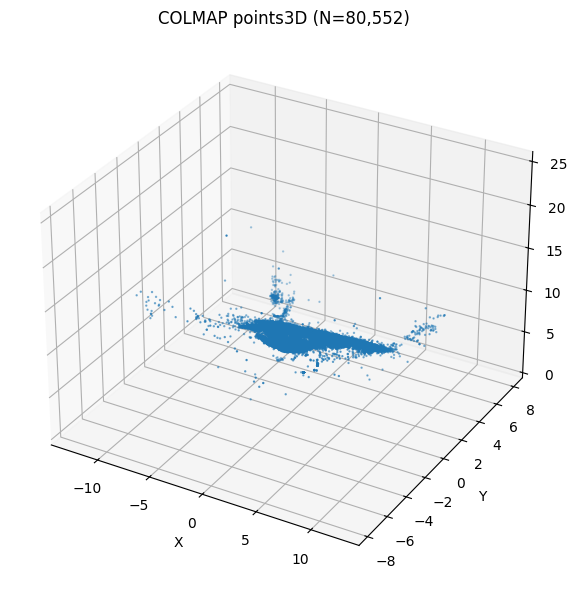

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ----------------------------
# Load from text: points_xyzrgb.txt
# Format per line: x y z r g b
# First line is a comment starting with '#'
# ----------------------------
txt_path = "points_xyzrgb.txt"  # <-- adjust path if needed

xyz_list = []
with open(txt_path, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split()
        if len(parts) < 3:
            continue
        x, y, z = map(float, parts[:3])
        xyz_list.append((x, y, z))

xyz = np.array(xyz_list, dtype=np.float64)
N = xyz.shape[0]
print("Loaded points:", N)

# ----------------------------
# Write Gmsh v2.2 ASCII .msh
# Nodes: 1..N
# Elements: N point elements (type 15), each references one node
# ----------------------------
msh_path = "points_only.msh"
with open(msh_path, "w", encoding="utf-8") as f:
    f.write("$MeshFormat\n")
    f.write("2.2 0 8\n")
    f.write("$EndMeshFormat\n")

    f.write("$Nodes\n")
    f.write(f"{N}\n")
    for i, (x, y, z) in enumerate(xyz, start=1):
        f.write(f"{i} {x:.10f} {y:.10f} {z:.10f}\n")
    f.write("$EndNodes\n")

    f.write("$Elements\n")
    f.write(f"{N}\n")
    # element_id  type=15  num_tags=2  phys=0 geom=0  node_id
    for i in range(1, N + 1):
        f.write(f"{i} 15 2 0 0 {i}\n")
    f.write("$EndElements\n")

print("Wrote:", msh_path, "points:", N)

# ----------------------------
# Visualize ALL points (3D scatter)
# ----------------------------
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], s=0.5)  # small markers
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title(f"COLMAP points3D (N={N:,})")
plt.tight_layout()
plt.show()

In [6]:
from __future__ import annotations
from pathlib import Path
import numpy as np


def _find_points3d(points3d_path: str | Path) -> Path:
    """
    Resolve points3D.txt robustly.
    - accepts relative paths
    - fixes the common missing 'images/' segment
    - searches under likely roots if still not found
    """
    p = Path(points3d_path).expanduser()

    # 1) direct
    if p.exists():
        return p.resolve()

    # 2) common mistake: missing "images/"
    #    e.g. scanning/png/... -> scanning/images/png/...
    p2 = Path(str(p).replace("/scanning/png/", "/scanning/images/png/"))
    if p2.exists():
        return p2.resolve()

    # 3) try under ~/DataStructure with the corrected expected location
    home_candidate = Path("~/DataStructure/numerical_analysis/FEA_meg/scanning/images/png/sparse_out/0_txt/points3D.txt").expanduser()
    if home_candidate.exists():
        return home_candidate.resolve()

    # 4) last resort: search locally from CWD (can take a bit, but reliable)
    cwd = Path.cwd()
    hits = list(cwd.rglob("points3D.txt"))
    if hits:
        # Prefer ones inside sparse_out/0_txt if present
        hits_sorted = sorted(
            hits,
            key=lambda x: (0 if "sparse_out/0_txt" in str(x).replace("\\", "/") else 1, len(str(x)))
        )
        return hits_sorted[0].resolve()

    raise FileNotFoundError(
        "points3D.txt not found.\n"
        f"Tried:\n  - {p}\n  - {p2}\n  - {home_candidate}\n"
        f"Also searched under: {cwd}"
    )


def convert_points3d_to_xyzrgb_txt_and_npy(
    points3d_path: str | Path = "png/sparse_out/0_txt/points3D.txt",
    out_xyzrgb_txt: str | Path = "points_xyzrgb.txt",
    out_xyz_npy: str | Path = "points_xyz.npy",
    out_xyzrgb_npy: str | Path = "points_xyzrgb.npy",
) -> dict:
    """
    Read COLMAP points3D.txt and write:
      - points_xyzrgb.txt : x y z r g b
      - points_xyz.npy    : Nx3 float64
      - points_xyzrgb.npy : Nx6 float64 (x,y,z,r,g,b)
    """
    points3d_path = _find_points3d(points3d_path)

    out_xyzrgb_txt = Path(out_xyzrgb_txt)
    out_xyz_npy = Path(out_xyz_npy)
    out_xyzrgb_npy = Path(out_xyzrgb_npy)

    xyz_list = []
    rgb_list = []
    err_list = []
    bad = 0

    with points3d_path.open("r", encoding="utf-8", errors="ignore") as fin:
        for line in fin:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            # id x y z r g b error ...
            if len(parts) < 8:
                bad += 1
                continue
            try:
                x = float(parts[1]); y = float(parts[2]); z = float(parts[3])
                r = int(parts[4]); g = int(parts[5]); b = int(parts[6])
                err = float(parts[7])
            except Exception:
                bad += 1
                continue

            r = max(0, min(255, r))
            g = max(0, min(255, g))
            b = max(0, min(255, b))

            xyz_list.append((x, y, z))
            rgb_list.append((r, g, b))
            err_list.append(err)

    xyz = np.asarray(xyz_list, dtype=np.float64)       # Nx3
    rgb = np.asarray(rgb_list, dtype=np.uint8)         # Nx3
    err = np.asarray(err_list, dtype=np.float64)       # Nx

    n = int(xyz.shape[0])

    # txt
    with out_xyzrgb_txt.open("w", encoding="utf-8") as fout:
        fout.write("# x y z r g b (extracted from COLMAP points3D.txt)\n")
        for (x, y, z), (r, g, b) in zip(xyz, rgb):
            fout.write(f"{x:.10f} {y:.10f} {z:.10f} {int(r)} {int(g)} {int(b)}\n")

    # npy
    np.save(out_xyz_npy, xyz)  # Nx3
    xyzrgb = np.column_stack([xyz, rgb.astype(np.float64)])  # Nx6
    np.save(out_xyzrgb_npy, xyzrgb)

    return {
        "source_used": str(points3d_path),
        "n_points": n,
        "bad_lines": int(bad),
        "mean_error": float(err.mean()) if n else None,
        "min_error": float(err.min()) if n else None,
        "max_error": float(err.max()) if n else None,
        "out_xyzrgb_txt": str(out_xyzrgb_txt.resolve()),
        "out_xyz_npy": str(out_xyz_npy.resolve()),
        "out_xyzrgb_npy": str(out_xyzrgb_npy.resolve()),
    }


if __name__ == "__main__":
    meta = convert_points3d_to_xyzrgb_txt_and_npy(
        # IMPORTANT: the correct relative path from your project is usually:
        # "images/png/sparse_out/0_txt/points3D.txt"
        points3d_path="images/png/sparse_out/0_txt/points3D.txt",
        out_xyzrgb_txt="points_xyzrgb.txt",
        out_xyz_npy="points_xyz.npy",
        out_xyzrgb_npy="points_xyzrgb.npy",
    )
    print("Conversion done:")
    for k, v in meta.items():
        print(f"  {k}: {v}")

Conversion done:
  source_used: /Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning/colmap_ws/ws_208_exhaustive_v1/txt/points3D.txt
  n_points: 80552
  bad_lines: 0
  mean_error: 1.2343016160601368
  min_error: 1.197023848290253e-05
  max_error: 3.8254189321772074
  out_xyzrgb_txt: /Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning/points_xyzrgb.txt
  out_xyz_npy: /Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning/points_xyz.npy
  out_xyzrgb_npy: /Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning/points_xyzrgb.npy


In [7]:
from __future__ import annotations
from pathlib import Path
import numpy as np

# ============================================================
# 0) Your existing path + conversion utilities (unchanged)
# ============================================================

def _find_points3d(points3d_path: str | Path) -> Path:
    p = Path(points3d_path).expanduser()
    if p.exists():
        return p.resolve()

    p2 = Path(str(p).replace("/scanning/png/", "/scanning/images/png/"))
    if p2.exists():
        return p2.resolve()

    home_candidate = Path(
        "~/DataStructure/numerical_analysis/FEA_meg/scanning/images/png/sparse_out/0_txt/points3D.txt"
    ).expanduser()
    if home_candidate.exists():
        return home_candidate.resolve()

    cwd = Path.cwd()
    hits = list(cwd.rglob("points3D.txt"))
    if hits:
        hits_sorted = sorted(
            hits,
            key=lambda x: (0 if "sparse_out/0_txt" in str(x).replace("\\", "/") else 1, len(str(x)))
        )
        return hits_sorted[0].resolve()

    raise FileNotFoundError(
        "points3D.txt not found.\n"
        f"Tried:\n  - {p}\n  - {p2}\n  - {home_candidate}\n"
        f"Also searched under: {cwd}"
    )


def convert_points3d_to_xyzrgb_txt_and_npy(
    points3d_path: str | Path = "images/png/sparse_out/0_txt/points3D.txt",
    out_xyzrgb_txt: str | Path = "points_xyzrgb.txt",
    out_xyz_npy: str | Path = "points_xyz.npy",
    out_xyzrgb_npy: str | Path = "points_xyzrgb.npy",
) -> dict:
    points3d_path = _find_points3d(points3d_path)

    out_xyzrgb_txt = Path(out_xyzrgb_txt)
    out_xyz_npy = Path(out_xyz_npy)
    out_xyzrgb_npy = Path(out_xyzrgb_npy)

    xyz_list, rgb_list, err_list = [], [], []
    bad = 0

    with points3d_path.open("r", encoding="utf-8", errors="ignore") as fin:
        for line in fin:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) < 8:
                bad += 1
                continue
            try:
                x = float(parts[1]); y = float(parts[2]); z = float(parts[3])
                r = int(parts[4]); g = int(parts[5]); b = int(parts[6])
                err = float(parts[7])
            except Exception:
                bad += 1
                continue

            r = max(0, min(255, r))
            g = max(0, min(255, g))
            b = max(0, min(255, b))

            xyz_list.append((x, y, z))
            rgb_list.append((r, g, b))
            err_list.append(err)

    xyz = np.asarray(xyz_list, dtype=np.float64)       # Nx3
    rgb = np.asarray(rgb_list, dtype=np.uint8)         # Nx3
    err = np.asarray(err_list, dtype=np.float64)       # Nx
    n = int(xyz.shape[0])

    with out_xyzrgb_txt.open("w", encoding="utf-8") as fout:
        fout.write("# x y z r g b (extracted from COLMAP points3D.txt)\n")
        for (x, y, z), (r, g, b) in zip(xyz, rgb):
            fout.write(f"{x:.10f} {y:.10f} {z:.10f} {int(r)} {int(g)} {int(b)}\n")

    np.save(out_xyz_npy, xyz)  # Nx3
    xyzrgb = np.column_stack([xyz, rgb.astype(np.float64)])  # Nx6
    np.save(out_xyzrgb_npy, xyzrgb)

    return {
        "source_used": str(points3d_path),
        "n_points": n,
        "bad_lines": int(bad),
        "mean_error": float(err.mean()) if n else None,
        "min_error": float(err.min()) if n else None,
        "max_error": float(err.max()) if n else None,
        "out_xyzrgb_txt": str(out_xyzrgb_txt.resolve()),
        "out_xyz_npy": str(out_xyz_npy.resolve()),
        "out_xyzrgb_npy": str(out_xyzrgb_npy.resolve()),
    }


# ============================================================
# 1) Closedness utilities (NO trimesh.edges_boundary)
# ============================================================

def boundary_edge_count_from_faces(F: np.ndarray) -> int:
    """
    Count boundary edges for a triangle mesh using only faces (pure NumPy).
    Boundary edge = undirected edge that appears exactly once.
    """
    F = np.asarray(F, dtype=np.int64)
    if F.ndim != 2 or F.shape[1] != 3:
        raise ValueError(f"F must be (M,3), got {F.shape}")

    E = np.vstack([
        F[:, [0, 1]],
        F[:, [1, 2]],
        F[:, [2, 0]],
    ])
    E = np.sort(E, axis=1)  # undirected
    _, counts = np.unique(E, axis=0, return_counts=True)
    return int(np.sum(counts == 1))


def check_surface_closed_for_tetwild(surface_mesh_path: str | Path) -> dict:
    import trimesh
    surface_mesh_path = Path(surface_mesh_path)
    if not surface_mesh_path.exists():
        raise FileNotFoundError(f"Surface mesh not found: {surface_mesh_path.resolve()}")

    m = trimesh.load(surface_mesh_path, process=False)
    if isinstance(m, trimesh.Scene):
        geoms = [g for g in m.geometry.values() if isinstance(g, trimesh.Trimesh)]
        if not geoms:
            raise ValueError("No Trimesh geometry found.")
        m = trimesh.util.concatenate(geoms)

    if m.faces is None or len(m.faces) == 0:
        raise ValueError(f"No faces found in mesh: {surface_mesh_path}")

    if m.faces.shape[1] != 3:
        m = m.triangulate()

    F = np.asarray(m.faces, dtype=np.int64)
    V = np.asarray(m.vertices, dtype=np.float64)

    bnd = boundary_edge_count_from_faces(F)
    is_watertight = bool(getattr(m, "is_watertight", (bnd == 0)))
    winding_ok = bool(getattr(m, "is_winding_consistent", False))

    return {
        "path": str(surface_mesh_path.resolve()),
        "vertices": int(V.shape[0]),
        "faces": int(F.shape[0]),
        "boundary_edge_count": int(bnd),
        "is_watertight_flag": is_watertight,      # trimesh's flag if available
        "is_winding_consistent": winding_ok,
        "tetwild_ready": bool(bnd == 0),
    }


def load_surface_as_VF(mesh_path: str | Path):
    import trimesh
    mesh_path = Path(mesh_path)
    m = trimesh.load(mesh_path, process=False)

    if isinstance(m, trimesh.Scene):
        geoms = [g for g in m.geometry.values() if isinstance(g, trimesh.Trimesh)]
        if not geoms:
            raise ValueError(f"No triangle mesh geometry found in: {mesh_path}")
        m = trimesh.util.concatenate(geoms)

    if m.faces is None or len(m.faces) == 0:
        raise ValueError(f"No faces found in mesh: {mesh_path}")
    if m.faces.shape[1] != 3:
        m = m.triangulate()

    V_in = np.asarray(m.vertices, dtype=np.float64)
    F_in = np.asarray(m.faces, dtype=np.int32)

    bnd = boundary_edge_count_from_faces(F_in)
    if bnd != 0:
        raise ValueError(
            f"Mesh not closed (boundary edges={bnd}). Fix watertightness before TetWild."
        )

    return V_in, F_in


def run_tetwild_from_closed_surface(mesh_path: str | Path):
    import pytetwild
    V_in, F_in = load_surface_as_VF(mesh_path)

    print("TetWild input:")
    print("  V_in:", V_in.shape, V_in.dtype)
    print("  F_in:", F_in.shape, F_in.dtype)

    print("Running TetWild refinement and tetrahedralization…")
    V_tet, T_tet = pytetwild.tetrahedralize(V_in, F_in)

    print("TetWild tetrahedral mesh generated ✓")
    print("  Vertices:", V_tet.shape)
    print("  Tets    :", T_tet.shape)
    return V_tet, T_tet


# ============================================================
# 2) Main (unchanged structure)
# ============================================================

if __name__ == "__main__":
    meta = convert_points3d_to_xyzrgb_txt_and_npy(
        points3d_path="images/png/sparse_out/0_txt/points3D.txt",
        out_xyzrgb_txt="points_xyzrgb.txt",
        out_xyz_npy="points_xyz.npy",
        out_xyzrgb_npy="points_xyzrgb.npy",
    )
    print("Conversion complete:")
    for k, v in meta.items():
        print(f"{k}: {v}")

    xyz = np.load(meta["out_xyz_npy"])
    print("\nLoaded xyz:", xyz.shape)

    # NOTE: your surface-building code stays the same as before;
    # just call check_surface_closed_for_tetwild() without edges_boundary now.
    #
    # Example:
    surf_info = check_surface_closed_for_tetwild("surface_hull.ply")
    print("Closedness:", surf_info)
    V_tet, T_tet = run_tetwild_from_closed_surface("surface_hull.ply")
    print("TetWild output:")
    print("  V_tet:", V_tet.shape)
    print("  T_tet:", T_tet.shape)

Conversion complete:
source_used: /Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning/colmap_ws/ws_208_exhaustive_v1/txt/points3D.txt
n_points: 80552
bad_lines: 0
mean_error: 1.2343016160601368
min_error: 1.197023848290253e-05
max_error: 3.8254189321772074
out_xyzrgb_txt: /Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning/points_xyzrgb.txt
out_xyz_npy: /Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning/points_xyz.npy
out_xyzrgb_npy: /Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning/points_xyzrgb.npy

Loaded xyz: (80552, 3)
Closedness: {'path': '/Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning/surface_hull.ply', 'vertices': 41, 'faces': 78, 'boundary_edge_count': 0, 'is_watertight_flag': True, 'is_winding_consistent': True, 'tetwild_ready': True}
TetWild input:
  V_in: (41, 3) float64
  F_in: (78, 3) int32
Running TetWild refinement and tetrahedralization…
Starting tetrahedralization process...
Starti

In [8]:
# ============================================================
# 3) TetWild display (drop-in, based on your current progress)
#    - Uses your existing run_tetwild_from_closed_surface(...)
#    - Displays the TET mesh as an outer surface (fast + clear)
# ============================================================

import numpy as np

def display_tetwild_result(V_tet: np.ndarray, T_tet: np.ndarray,
                          show_edges: bool = False,
                          show_points: bool = False):
    """
    Visualize TetWild tetrahedral mesh output.
    Shows the OUTER surface of the tet mesh (recommended).
    """
    import pyvista as pv

    V = np.asarray(V_tet, dtype=np.float64)
    T = np.asarray(T_tet, dtype=np.int64)

    # VTK unstructured grid: cells = [4, a, b, c, d] per tetra
    cells = np.hstack([np.full((T.shape[0], 1), 4, dtype=np.int64), T]).ravel()
    celltypes = np.full(T.shape[0], pv.CellType.TETRA, dtype=np.uint8)

    grid = pv.UnstructuredGrid(cells, celltypes, V)

    # Outer surface is much lighter to render than all internal tets
    surf = grid.extract_surface().triangulate()

    p = pv.Plotter()
    p.add_mesh(surf, show_edges=show_edges)
    if show_points:
        p.add_points(V, render_points_as_spheres=True, point_size=2)
    p.add_axes()
    p.show()


# ============================================================
# 2) Main (your structure) — add display right after TetWild
# ============================================================

if __name__ == "__main__":
    meta = convert_points3d_to_xyzrgb_txt_and_npy(
        points3d_path="images/png/sparse_out/0_txt/points3D.txt",
        out_xyzrgb_txt="points_xyzrgb.txt",
        out_xyz_npy="points_xyz.npy",
        out_xyzrgb_npy="points_xyzrgb.npy",
    )
    print("Conversion complete:")
    for k, v in meta.items():
        print(f"{k}: {v}")

    xyz = np.load(meta["out_xyz_npy"])
    print("\nLoaded xyz:", xyz.shape)

    # You already have a closed surface here:
    surf_info = check_surface_closed_for_tetwild("surface_hull.ply")
    print("Closedness:", surf_info)

    # Run TetWild (your existing method)
    V_tet, T_tet = run_tetwild_from_closed_surface("surface_hull.ply")
    print("TetWild output:")
    print("  V_tet:", V_tet.shape)
    print("  T_tet:", T_tet.shape)

    # Display TetWild result
    display_tetwild_result(V_tet, T_tet, show_edges=False, show_points=False)

Conversion complete:
source_used: /Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning/colmap_ws/ws_208_exhaustive_v1/txt/points3D.txt
n_points: 80552
bad_lines: 0
mean_error: 1.2343016160601368
min_error: 1.197023848290253e-05
max_error: 3.8254189321772074
out_xyzrgb_txt: /Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning/points_xyzrgb.txt
out_xyz_npy: /Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning/points_xyz.npy
out_xyzrgb_npy: /Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning/points_xyzrgb.npy

Loaded xyz: (80552, 3)
Closedness: {'path': '/Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning/surface_hull.ply', 'vertices': 41, 'faces': 78, 'boundary_edge_count': 0, 'is_watertight_flag': True, 'is_winding_consistent': True, 'tetwild_ready': True}
TetWild input:
  V_in: (41, 3) float64
  F_in: (78, 3) int32
Running TetWild refinement and tetrahedralization…
Starting tetrahedralization process...
Starti

Python(15049) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Widget(value='<iframe src="http://localhost:52414/index.html?ui=P_0x14e7e97f0_0&reconnect=auto" class="pyvista…

In [9]:
# ============================================================
# 3) TetWild display (monotone translucent blue + edges + legend)
# ============================================================

import numpy as np

def display_tetwild_result(
    V_tet: np.ndarray,
    T_tet: np.ndarray,
    *,
    # visual style
    surface_opacity: float = 0.22,
    edge_opacity: float = 0.55,
    edge_line_width: float = 1.2,

    # what to visualize / legend
    legend_title: str = "Metric",
    metric_mode: str = "radius",  # "radius" or "z" or "none"
    show_scalar_bar: bool = True,

    # toggles
    show_edges: bool = True,
    show_points: bool = False,
    point_size: float = 3.0,
):
    """
    Visualize TetWild tetrahedral mesh output (outer surface).
    Monotone translucent blue surface + edge overlay + legend/scalarbar.

    metric_mode:
      - "radius": scalar = ||x|| (good default, gives some variation)
      - "z":      scalar = z coordinate
      - "none":   no scalar mapping; still shows monotone surface
    """
    import pyvista as pv

    V = np.asarray(V_tet, dtype=np.float64)
    T = np.asarray(T_tet, dtype=np.int64)

    # VTK unstructured grid: cells = [4, a, b, c, d] per tetra
    cells = np.hstack([np.full((T.shape[0], 1), 4, dtype=np.int64), T]).ravel()
    celltypes = np.full(T.shape[0], pv.CellType.TETRA, dtype=np.uint8)
    grid = pv.UnstructuredGrid(cells, celltypes, V)

    # Outer surface: fast and clear
    surf = grid.extract_surface().triangulate()

    # ------------------------------------------------------------
    # Metric for legend/scalarbar (optional)
    # ------------------------------------------------------------
    scalars_name = None
    if metric_mode == "radius":
        s = np.linalg.norm(surf.points, axis=1)
        scalars_name = "radius"
        surf.point_data[scalars_name] = s
        if legend_title == "Metric":
            legend_title = "Radius |x|"
    elif metric_mode == "z":
        s = surf.points[:, 2]
        scalars_name = "z"
        surf.point_data[scalars_name] = s
        if legend_title == "Metric":
            legend_title = "Z"
    elif metric_mode == "none":
        scalars_name = None
    else:
        raise ValueError(f"Unknown metric_mode={metric_mode!r}")

    # ------------------------------------------------------------
    # Plotting
    # ------------------------------------------------------------
    p = pv.Plotter()
    p.set_background("white")  # clean

    # --- Monotone translucent blue surface ---
    # Use a single blue color + opacity; if scalars provided, still
    # keep it "monotone" by using a single-hue colormap.
    surface_kwargs = dict(
        opacity=surface_opacity,
        smooth_shading=True,
        specular=0.12,
        specular_power=12,
    )

    if scalars_name is None:
        p.add_mesh(
            surf,
            color=(0.18, 0.45, 0.85),  # monotone blue
            **surface_kwargs,
        )
    else:
        # Single-hue colormap -> still monotone. "Blues" is a safe builtin.
        p.add_mesh(
            surf,
            scalars=scalars_name,
            cmap="Blues",
            show_scalar_bar=show_scalar_bar,
            scalar_bar_args=dict(
                title=legend_title,
                vertical=True,
                title_font_size=14,
                label_font_size=11,
                n_labels=4,
                shadow=True,
            ),
            **surface_kwargs,
        )

    # --- Edge overlay (translucent blue shade) ---
    if show_edges:
        edges = surf.extract_all_edges()
        p.add_mesh(
            edges,
            color=(0.10, 0.30, 0.65),  # slightly deeper blue
            opacity=edge_opacity,
            line_width=edge_line_width,
        )

    # --- Optional points ---
    if show_points:
        p.add_points(
            V,
            render_points_as_spheres=True,
            point_size=point_size,
            color=(0.10, 0.30, 0.65),
            opacity=0.8,
        )

    # Axes + legend text
    p.add_axes()
    p.add_text(
        "TetWild outer surface\n(translucent blue) + edge overlay",
        position="upper_left",
        font_size=11,
        color="black",
        shadow=True,
    )

    p.show()


# ============================================================
# 2) Main (your structure) — call display after TetWild
# ============================================================

if __name__ == "__main__":
    meta = convert_points3d_to_xyzrgb_txt_and_npy(
        points3d_path="images/png/sparse_out/0_txt/points3D.txt",
        out_xyzrgb_txt="points_xyzrgb.txt",
        out_xyz_npy="points_xyz.npy",
        out_xyzrgb_npy="points_xyzrgb.npy",
    )
    print("Conversion complete:")
    for k, v in meta.items():
        print(f"{k}: {v}")

    xyz = np.load(meta["out_xyz_npy"])
    print("\nLoaded xyz:", xyz.shape)

    surf_info = check_surface_closed_for_tetwild("surface_hull.ply")
    print("Closedness:", surf_info)

    V_tet, T_tet = run_tetwild_from_closed_surface("surface_hull.ply")
    print("TetWild output:")
    print("  V_tet:", V_tet.shape)
    print("  T_tet:", T_tet.shape)

    display_tetwild_result(
        V_tet,
        T_tet,
        show_edges=True,
        surface_opacity=0.22,
        edge_opacity=0.55,
        metric_mode="radius",        # try "none" if you want pure monotone
        show_scalar_bar=True,
        legend_title="Radius |x|",
    )

Conversion complete:
source_used: /Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning/colmap_ws/ws_208_exhaustive_v1/txt/points3D.txt
n_points: 80552
bad_lines: 0
mean_error: 1.2343016160601368
min_error: 1.197023848290253e-05
max_error: 3.8254189321772074
out_xyzrgb_txt: /Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning/points_xyzrgb.txt
out_xyz_npy: /Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning/points_xyz.npy
out_xyzrgb_npy: /Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning/points_xyzrgb.npy

Loaded xyz: (80552, 3)
Closedness: {'path': '/Users/eliguli712/DataStructure/numerical_analysis/FEA_meg/scanning/surface_hull.ply', 'vertices': 41, 'faces': 78, 'boundary_edge_count': 0, 'is_watertight_flag': True, 'is_winding_consistent': True, 'tetwild_ready': True}
TetWild input:
  V_in: (41, 3) float64
  F_in: (78, 3) int32
Running TetWild refinement and tetrahedralization…
Starting tetrahedralization process...
Starti

Widget(value='<iframe src="http://localhost:52414/index.html?ui=P_0x15cd716d0_1&reconnect=auto" class="pyvista…